# 二维交互分箱（OptimalBinning2D）示例

本示例展示如何使用 `OptimalBinning2D` 对两个特征进行交叉分箱分析，
用于揭示特征间的交互效应。


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hscredit.core.binning import OptimalBinning2D

## 1. 加载数据

In [2]:
# 加载真实业务数据
df = pd.read_excel('hscredit_yyp.xlsx')

# 目标列：使用 MOB1>3 作为演示标签
df['target_demo'] = (df['MOB1'] > 3).astype(int)
target = 'target_demo'

# 排除字段
exclude_cols = {'MOB1', 'MOB2', 'target_demo'}
features = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]

# 优先选用含 C3 的数值评分列
def pick_feature(cols):
    for c in cols:
        if 'C3' in str(c) or 'c3' in str(c):
            return c
    return cols[0]

feat1 = pick_feature(features)  # 特征1
feat2 = features[1] if len(features) > 1 else features[0]  # 特征2

print(f"样本数: {len(df)}, 坏样本率: {df[target].mean():.2%}")
print(f"特征1: {feat1}")
print(f"特征2: {feat2}")
print(df[[feat1, feat2, 'MOB1', target]].head())

样本数: 970, 坏样本率: 16.70%
特征1: 中智小牛分C3
特征2: 放款金额
   中智小牛分C3  放款金额  MOB1  target_demo
0      NaN  1399     0            0
1      NaN  1399     0            0
2      NaN  3960     0            0
3      NaN  3960     0            0
4      NaN  1399     0            0


## 2. 拟合 OptimalBinning2D

In [3]:
# 创建 OptimalBinning2D 实例
binner = OptimalBinning2D(max_n_bins=5)

# 拟合模型
binner.fit(df, y=df[target], features=[feat1, feat2])

# 查看基本信息
print(f"特征1分箱数: {binner.n_bins_x_}")
print(f"特征2分箱数: {binner.n_bins_y_}")
print(f"交互IV值: {binner.iv_interaction_:.4f}")

特征1分箱数: 5
特征2分箱数: 5
交互IV值: 0.5105


## 3. 交叉分箱统计表

In [4]:
# 获取交叉分箱统计表
cross_table = binner.get_cross_table()
print("交叉分箱统计表:")
print(cross_table)

交叉分箱统计表:
        特征1   特征2  分箱1  分箱2           分箱1标签         分箱2标签  样本总数  好样本数  坏样本数  \
0   中智小牛分C3  放款金额    0    0   [-inf, 550.0)  [-inf, 1446)    21    17     4   
1   中智小牛分C3  放款金额    0    1   [-inf, 550.0)  [1446, 4206)    14    10     4   
2   中智小牛分C3  放款金额    0    2   [-inf, 550.0)  [4206, 4368)     1     1     0   
3   中智小牛分C3  放款金额    0    3   [-inf, 550.0)  [4368, 5850)    15     8     7   
4   中智小牛分C3  放款金额    0    4   [-inf, 550.0)  [5850, +inf)    10    10     0   
5   中智小牛分C3  放款金额    1    0  [550.0, 602.4)  [-inf, 1446)    15    13     2   
6   中智小牛分C3  放款金额    1    1  [550.0, 602.4)  [1446, 4206)    16    12     4   
7   中智小牛分C3  放款金额    1    2  [550.0, 602.4)  [4206, 4368)     1     1     0   
8   中智小牛分C3  放款金额    1    3  [550.0, 602.4)  [4368, 5850)    15    12     3   
9   中智小牛分C3  放款金额    1    4  [550.0, 602.4)  [5850, +inf)    15    15     0   
10  中智小牛分C3  放款金额    2    0  [602.4, 663.6)  [-inf, 1446)    19    17     2   
11  中智小牛分C3  放款金额    2    1  [602.4, 663.6)

## 4. 高风险交叉区间

In [5]:
# 获取高风险交叉区间（坏账率>35%）
high_risk = cross_table[cross_table['坏样本率'] > 0.35]
print("高风险交叉区间（坏账率>35%）:")
print(high_risk)

高风险交叉区间（坏账率>35%）:
        特征1   特征2  分箱1  分箱2          分箱1标签         分箱2标签  样本总数  好样本数  坏样本数  \
3   中智小牛分C3  放款金额    0    3  [-inf, 550.0)  [4368, 5850)    15     8     7   
22  中智小牛分C3  放款金额    4    2  [713.0, +inf)  [4206, 4368)     2     1     1   

        坏样本率      样本占比    分档WOE值     分档IV值     LIFT值  
3   0.466667  0.048860  1.602348  0.194721  3.114493  
22  0.500000  0.006515  1.735879  0.031086  3.336957  


## 5. 可视化（feat1 × feat2）

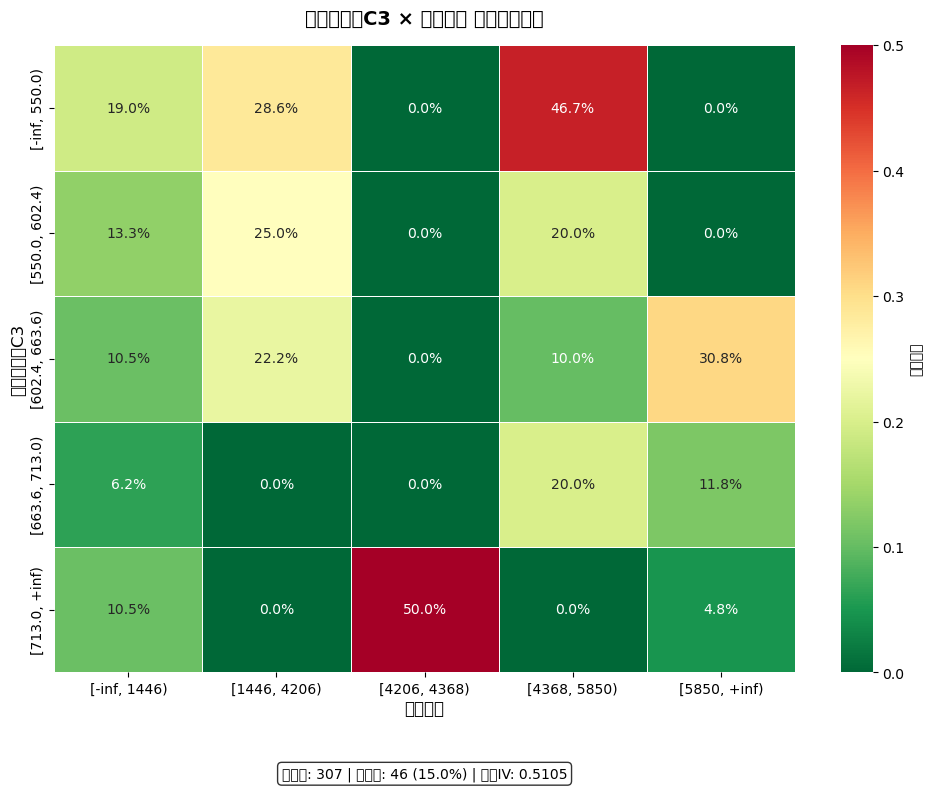

In [6]:
# 绘制坏样本率热力图
fig = binner.plot(metric='bad_rate', figsize=(10, 8))
plt.show()

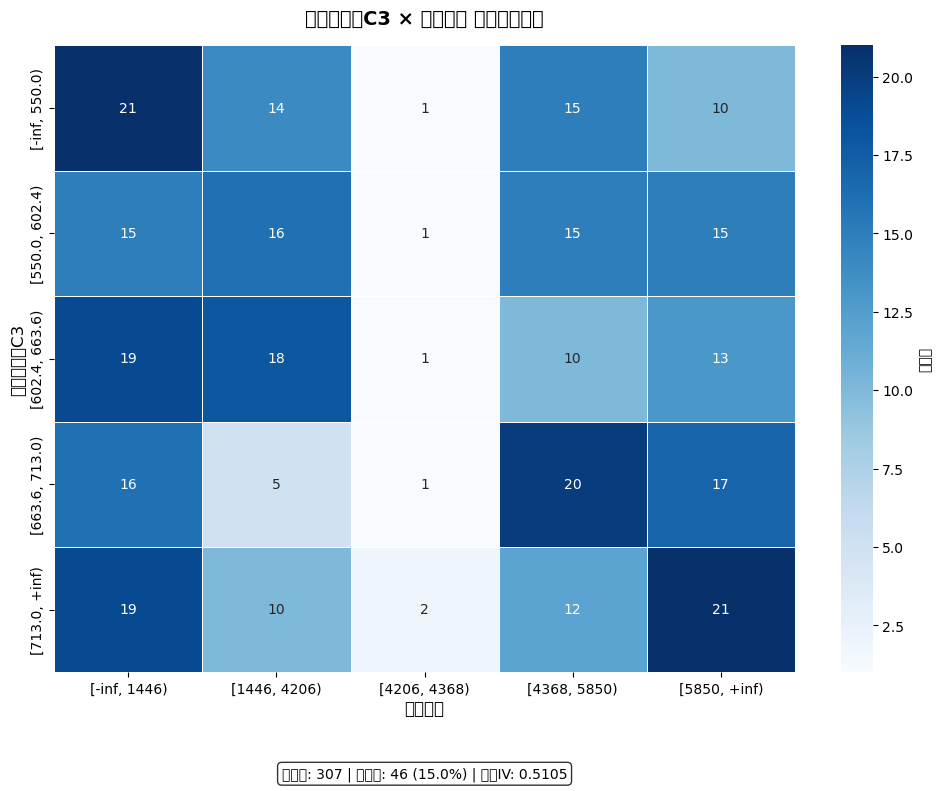

In [7]:
# 绘制样本数热力图
fig = binner.plot(metric='count', fmt='d', figsize=(10, 8))
plt.show()

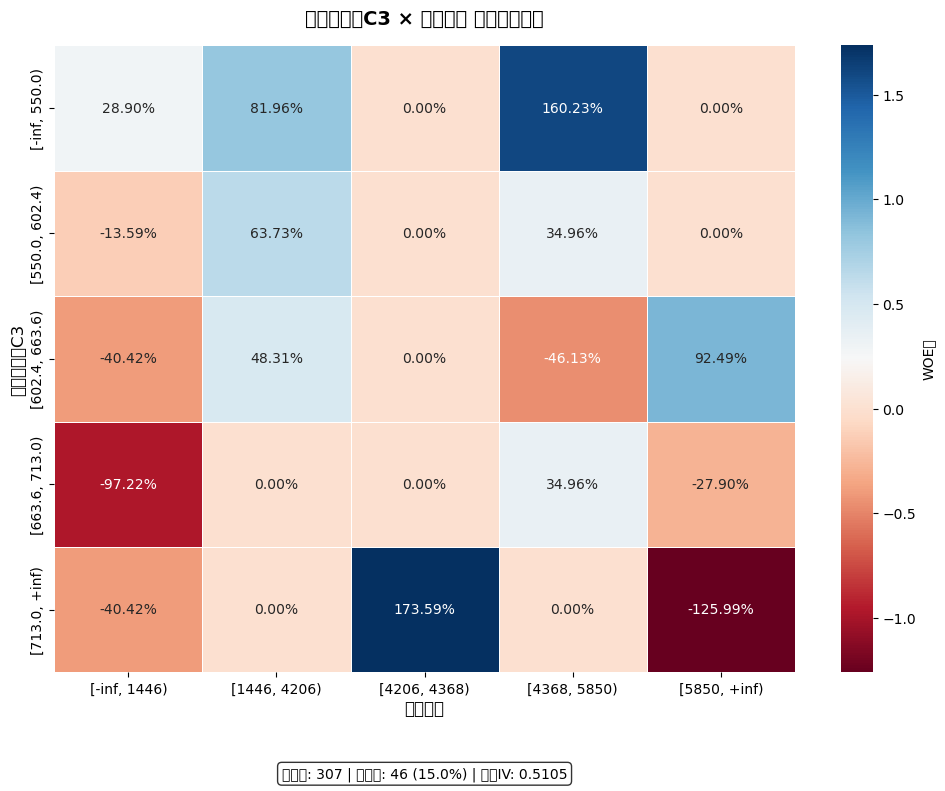

In [8]:
# 绘制 WOE 热力图
fig = binner.plot(metric='woe', figsize=(10, 8))
plt.show()

## 6. Transform 转换

In [9]:
# Transform: 将原始特征转换为分箱索引
X_binned = binner.transform(df[[feat1, feat2]], metric='indices')
print("分箱转换结果:")
print(X_binned.head())

分箱转换结果:
   中智小牛分C3  放款金额
0       -1     0
1       -1     0
2       -1     1
3       -1     1
4       -1     0


In [10]:
# WOE 转换
X_woe = binner.transform(df[[feat1, feat2]], metric='woe')
print("WOE转换结果:")
print(X_woe.head())

WOE转换结果:
   中智小牛分C3  放款金额
0      NaN   NaN
1      NaN   NaN
2      NaN   NaN
3      NaN   NaN
4      NaN   NaN


## 7. 获取矩阵

In [11]:
# 获取坏样本率矩阵
bad_rate_matrix = binner.get_bad_rate_matrix()
print("坏样本率矩阵:")
print(bad_rate_matrix.round(3))

坏样本率矩阵:
分箱2标签           [-inf, 1446)  [1446, 4206)  [4206, 4368)  [4368, 5850)  \
分箱1标签                                                                    
[-inf, 550.0)          0.190         0.286           0.0         0.467   
[550.0, 602.4)         0.133         0.250           0.0         0.200   
[602.4, 663.6)         0.105         0.222           0.0         0.100   
[663.6, 713.0)         0.062         0.000           0.0         0.200   
[713.0, +inf)          0.105         0.000           0.5         0.000   

分箱2标签           [5850, +inf)  
分箱1标签                         
[-inf, 550.0)          0.000  
[550.0, 602.4)         0.000  
[602.4, 663.6)         0.308  
[663.6, 713.0)         0.118  
[713.0, +inf)          0.048  


In [12]:
# 获取 IV 矩阵
iv_matrix = binner.get_iv_matrix()
print("IV矩阵:")
print(iv_matrix.round(4))

IV矩阵:
分箱2标签           [-inf, 1446)  [1446, 4206)  [4206, 4368)  [4368, 5850)  \
分箱1标签                                                                    
[-inf, 550.0)         0.0063        0.0399        0.0000        0.1947   
[550.0, 602.4)        0.0009        0.0261        0.0000        0.0067   
[602.4, 663.6)        0.0088        0.0161        0.0000        0.0059   
[663.6, 713.0)        0.0347        0.0000        0.0000        0.0090   
[713.0, +inf)         0.0088        0.0000        0.0311        0.0000   

分箱2标签           [5850, +inf)  
分箱1标签                         
[-inf, 550.0)         0.0000  
[550.0, 602.4)        0.0000  
[602.4, 663.6)        0.0485  
[663.6, 713.0)        0.0039  
[713.0, +inf)         0.0692  


## 8. 自定义分箱规则

特征1默认切分点: [550.  602.4 663.6 713. ]
特征2默认切分点: [1446. 4206. 4368. 5850.]


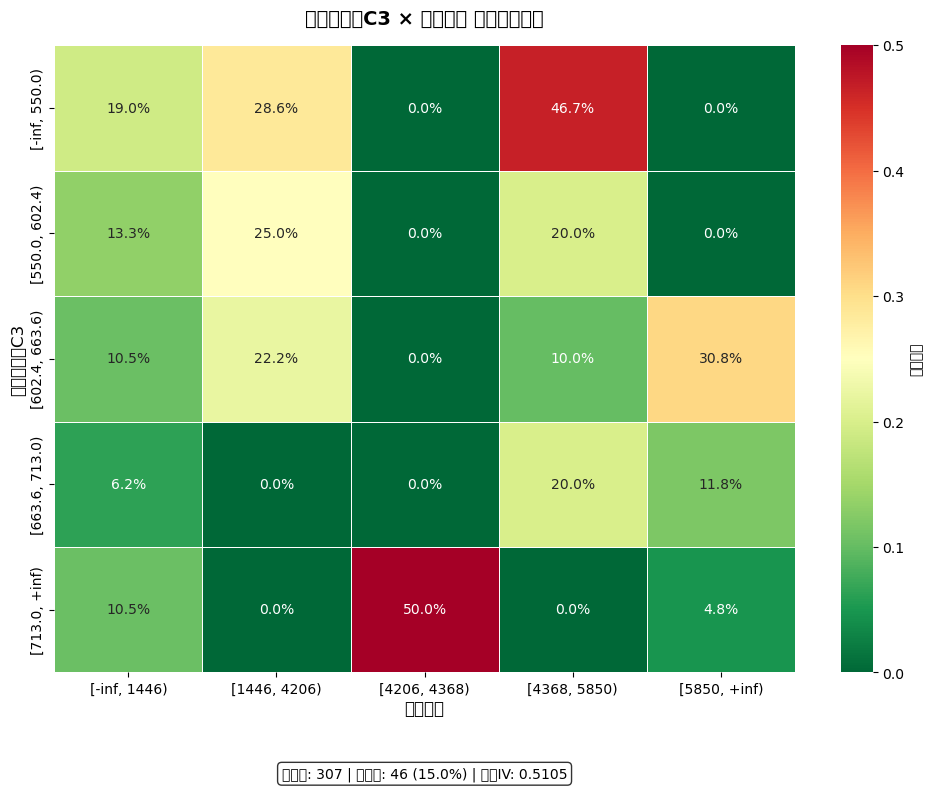

In [13]:
# 用户自定义切分点（基于默认分箱的切分点微调）
default_splits_x = binner.splits_x_
default_splits_y = binner.splits_y_

print(f"特征1默认切分点: {default_splits_x}")
print(f"特征2默认切分点: {default_splits_y}")

# 使用自定义切分点创建新的分箱器
binner_custom = OptimalBinning2D(
    user_splits_x=default_splits_x,
    user_splits_y=default_splits_y
)
binner_custom.fit(df, y=df[target], features=[feat1, feat2])

fig = binner_custom.plot(metric='bad_rate', figsize=(10, 8))
plt.show()

## 9. 批量特征分箱

In [14]:
# 对多对特征进行批量分箱分析
selected_pairs = [
    [features[0], features[1]],
]

if len(features) > 2:
    selected_pairs.append([features[0], features[2]])

results = []
for feat_pair in selected_pairs:
    try:
        b = OptimalBinning2D(max_n_bins=4)
        b.fit(df, y=df[target], features=feat_pair)
        results.append({
            '特征1': feat_pair[0],
            '特征2': feat_pair[1],
            '分箱数X': b.n_bins_x_,
            '分箱数Y': b.n_bins_y_,
            '交互IV': round(b.iv_interaction_, 4)
        })
    except Exception as e:
        results.append({
            '特征1': feat_pair[0],
            '特征2': feat_pair[1],
            '错误': str(e)
        })

print(pd.DataFrame(results))

    特征1          特征2  分箱数X  分箱数Y    交互IV
0  客户编号         放款金额     4     4  0.0831
1  客户编号  CURRENT_DPD     4     3  2.7474


---

## 总结

`OptimalBinning2D` 提供了以下功能：

1. **fit**: 对两个特征分别进行分箱，计算交叉分箱统计
2. **transform**: 将新数据映射到二维分箱索引或标签
3. **get_cross_table**: 获取二维交叉分箱统计表
4. **get_bad_rate_matrix / get_count_matrix / get_woe_matrix / get_iv_matrix**: 获取各种指标的矩阵
5. **plot**: 绘制交互分箱热力图

适用于：
- 特征交互效应分析（如年龄×收入、信用分×负债率）
- 风险矩阵分析
- 交叉分箱风险热力图